In [1]:
import tensorflow as tf
from tensorflow.keras import datasets

In [2]:
# Load dataset
(x_train,y_train),(x_test,y_test)=datasets.mnist.load_data()

In [3]:
print(x_train.shape)

(60000, 28, 28)


In [4]:
#preprocess image

#normalize pixel value

x_train=x_train / 255.0
x_test= x_test / 255.0

In [5]:
# Reshape the image data

x_train=x_train.reshape (-1,28,28,1)
x_test=x_test.reshape (-1,28,28,1)

In [6]:
# build a CNN model\

from tensorflow.keras import layers, models

In [10]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),   ##32 is the number of filters applied
    layers.MaxPooling2D((2,2)),  # divide pixels into 2/2 ratio(reduces the configuration)
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

In [46]:
# Compile & Train

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train,y_train,
          epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9924 - loss: 0.0243
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9946 - loss: 0.0174
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9956 - loss: 0.0134


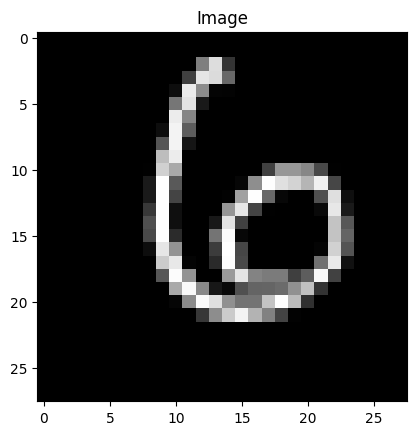

In [49]:
# input test image

import numpy as np
import matplotlib.pyplot as plt

image=x_test[100]

plt.imshow(image.squeeze(),cmap='grey')
plt.title("Image")
plt.show()

In [50]:
prediction=model.predict(image.reshape(1,28,28,1))
print("Predicted number is :",np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted number is : 6


In [54]:
from PIL import Image

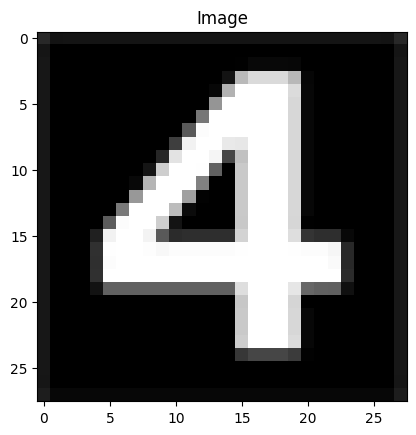

In [60]:
img= Image.open("four.png").convert("L").resize((28,28))
img=255 - np.array(img)
img = img / 255.0
img = img.reshape(1, 28, 28, 1)

plt.imshow(img.squeeze(),cmap='grey')
plt.title("Image")
plt.show()

In [61]:
pred= model.predict(img)
print("Predicted digit :",np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted digit : 4
